# Predicting Titanic Survival

This notebook version is built from your uploaded Python script and includes executed outputs.
Because the runtime here has no internet access, the notebook uses a **local Titanic CSV** available in the environment instead of `seaborn.load_dataset("titanic")`.

Source files used:
- `Predicting_Titanic_Survival.py`
- `Titanic_Survival_README.md`


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [2]:

LOCAL_TITANIC_PATH = "/opt/pyvenv/lib/python3.13/site-packages/gradio/media_assets/data/titanic.csv"

def load_data():
    df = pd.read_csv(LOCAL_TITANIC_PATH)
    cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
    return df[cols].rename(columns=str.lower)

def preprocess(df):
    df = df.dropna().copy()
    df["sex"] = df["sex"].map({"male": 0, "female": 1})
    return df

def split(df):
    X = df.drop("survived", axis=1)
    y = df["survived"]
    return train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

def train(X_train, y_train, X_train_scaled):
    models = {}

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    models["Logistic Regression"] = lr

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    models["KNN"] = knn

    dt = DecisionTreeClassifier(max_depth=4, random_state=42)
    dt.fit(X_train, y_train)
    models["Decision Tree"] = dt

    return models

def evaluate(models, X_test, X_test_scaled, y_test):
    results = {}

    for name, model in models.items():
        if name in ["Logistic Regression", "KNN"]:
            preds = model.predict(X_test_scaled)
        else:
            preds = model.predict(X_test)

        print(f"\n{name}")
        print(classification_report(y_test, preds))
        acc = accuracy_score(y_test, preds)
        print("Accuracy:", acc)
        results[name] = acc

    return results

def plot_results(results):
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), results.values())
    plt.title("Model Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    plt.ylim(0.70, 0.85)
    plt.show()


In [3]:

df = load_data()
df = preprocess(df)

print("Dataset shape after preprocessing:", df.shape)
df.head()


Dataset shape after preprocessing: (714, 7)


,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


In [4]:

X_train, X_test, y_train, y_test = split(df)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = train(X_train, y_train, X_train_scaled)
results = evaluate(models, X_test, X_test_scaled, y_test)
results



Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.82      0.83        85
           1       0.75      0.76      0.75        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143

Accuracy: 0.7972027972027972

KNN
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        85
           1       0.71      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143

Accuracy: 0.7622377622377622

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        85
           1       0.77      0.74      0.75        58

    accuracy                           0.80       143
   macro avg       0.80      

{'Logistic Regression': 0.7972027972027972,
 'KNN': 0.7622377622377622,
 'Decision Tree': 0.8041958041958042}

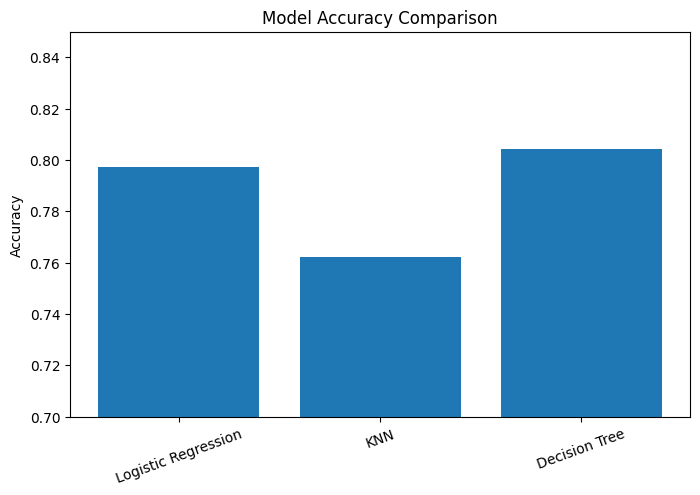

In [5]:

plot_results(results)


In [6]:

best_model = max(results, key=results.get)
print("Best model based on accuracy:", best_model)
print("Best accuracy:", round(results[best_model], 4))


Best model based on accuracy: Decision Tree
Best accuracy: 0.8042
